In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import re

In [14]:
first_round = pd.read_csv("datos/classification first round/classification_final.csv")
second_round = pd.read_csv("datos/classification second_round/classification_secondRound_final.csv")

classifiers_first = pd.read_csv("datos/classification first round/classifiers_final.csv")
classifiers_second = pd.read_csv("datos/classification second_round/classifiers_secondRound_final.csv")

In [15]:
first_round = first_round[['id', 'classifier_id', 'ad_id', 'classification', 'ease', 'workday', 'timestamp']]

## Classifiers

Two classifiers used different email in both classification rounds
- magdalena.arismendi@mail.udp.cl = magda.arismendi@gmail.com
- mjarayaf@uc.cl = matilde.arfu@gmail.com

To identify them we use just the first email that was used in the firs classification

In [4]:
classifiers_second['email'][14] = 'mjarayaf@uc.cl'
classifiers_second['email'][3] = 'magdalena.arismendi@mail.udp.cl'

/tmp/ipykernel_34946/1207430555.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  classifiers_second['email'][14] = 'mjarayaf@uc.cl'
/tmp/ipykernel_34946/1207430555.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  classifiers_second['email'][3] = 'magdalena.arismendi@mail.udp.cl'


## Classifications

In [5]:
first_round['classification'].value_counts()

classification
Not WFH    11120
WFH         4880
Name: count, dtype: int64

In [6]:
first_round['ease'].value_counts()

ease
easy      12264
medium     2976
hard        760
Name: count, dtype: int64

In [7]:
first_round['workday'].value_counts()

workday
full         10454
not clear     3490
part          2056
Name: count, dtype: int64

In [8]:
second_round['classification'].value_counts()

classification
tot_remote          1546
not_remote           848
not_clear_remote     823
semi_remote          807
semi_presence        579
temp_remote          527
Name: count, dtype: int64

In [9]:
second_round['ease'].value_counts()

ease
easy      3985
medium     987
hard       158
Name: count, dtype: int64

## Agreement

In [6]:
classifications_m = pd.merge(first_round, second_round, on='ad_id', how='outer', suffixes=('_first', '_second'))

classifications agreement first round

In [7]:
unique_class_counts = first_round.groupby('ad_id')['classification'].nunique()

In [8]:
# Ads where both classifications are the same
same_classification = unique_class_counts[unique_class_counts == 1].count()

# Ads where the classifications differ
different_classification = unique_class_counts[unique_class_counts == 2].count()

print("Number of ads with same classification:", same_classification)
print("Number of ads with different classification:", different_classification)

Number of ads with same classification: 7750
Number of ads with different classification: 250


Indicator by classifier

In [9]:
# Step 1: For each ad, determine if the classifications agree or disagree
# We assume each ad appears exactly twice.
ad_agreement = first_round.groupby('ad_id')['classification'].nunique().reset_index()
ad_agreement['disagreement'] = ad_agreement['classification'].apply(lambda x: 0 if x == 1 else 1)

# Step 2: Merge the disagreement indicator back to the original DataFrame
df_first = first_round.merge(ad_agreement[['ad_id', 'disagreement']], on='ad_id', how='left')

# Step 3: For each classifier, compute:
#   - The total number of ads classified
#   - The sum of disagreements (i.e. the number of ads for which their classification did not match the other classifier's)
disagreement_by_classifier = df_first.groupby('classifier_id')['disagreement'].agg(total_ads='count', total_disagreements='sum')
disagreement_by_classifier['disagreement_rate'] = disagreement_by_classifier['total_disagreements'] / disagreement_by_classifier['total_ads']

In [10]:
disagreement_by_classifier = disagreement_by_classifier.sort_values(by='disagreement_rate', ascending=False)

In [11]:
disagreement_by_classifier = pd.merge(disagreement_by_classifier, classifiers_first, left_on='classifier_id', right_on='id', how='left')
disagreement_by_classifier.to_csv('datos/disagreement_by_classifier_first_round.csv')

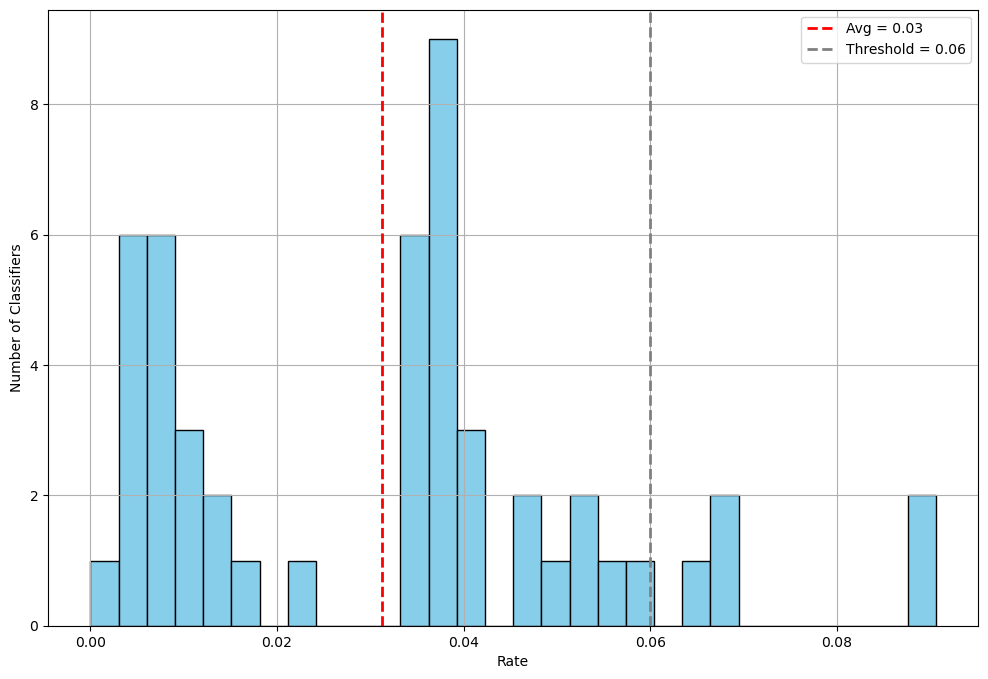

In [12]:
overall_avg = disagreement_by_classifier['disagreement_rate'].mean()
# Plot the histogram with average line
plt.figure(figsize=(12, 8))
plt.hist(disagreement_by_classifier['disagreement_rate'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(overall_avg, color='red', linestyle='dashed', linewidth=2, label=f'Avg = {overall_avg:.2f}')
plt.axvline(0.06, color='gray', linestyle='dashed', linewidth=2, label=f'Threshold = {0.06:.2f}')
#plt.title('Dissagreement rate by classifier, first round')
plt.xlabel('Rate')
plt.ylabel('Number of Classifiers')
plt.legend()
plt.grid(True)
plt.show()

Second round

In [17]:
unique_class_counts = second_round.groupby('ad_id')['classification'].nunique()

In [18]:
# Ads where both classifications are the same
same_classification = unique_class_counts[unique_class_counts == 1].count()

# Ads where the classifications differ
different_classification = unique_class_counts[unique_class_counts == 2].count()

print("Number of ads with same classification:", same_classification)
print("Number of ads with different classification:", different_classification)

Number of ads with same classification: 1801
Number of ads with different classification: 764


Indicator by classifier

In [19]:
# Step 1: For each ad, determine if the classifications agree or disagree
# We assume each ad appears exactly twice.
ad_agreement = second_round.groupby('ad_id')['classification'].nunique().reset_index()
ad_agreement['disagreement'] = ad_agreement['classification'].apply(lambda x: 0 if x == 1 else 1)

# Step 2: Merge the disagreement indicator back to the original DataFrame
df_second = second_round.merge(ad_agreement[['ad_id', 'disagreement']], on='ad_id', how='left')

# Step 3: For each classifier, compute:
#   - The total number of ads classified
#   - The sum of disagreements (i.e. the number of ads for which their classification did not match the other classifier's)
disagreement_by_classifier_second = df_second.groupby('classifier_id')['disagreement'].agg(total_ads='count', total_disagreements='sum')
disagreement_by_classifier_second['disagreement_rate'] = disagreement_by_classifier_second['total_disagreements'] / disagreement_by_classifier_second['total_ads']

In [20]:
disagreement_by_classifier = disagreement_by_classifier.sort_values(by='disagreement_rate', ascending=False)

In [21]:
disagreement_by_classifier_second = pd.merge(disagreement_by_classifier_second, classifiers_second, left_on='classifier_id', right_on='id', how='left')
disagreement_by_classifier_second.to_csv('datos/disagreement_by_classifier_second_round.csv')

Indicator by classifier after merging classification categories in second round

In [22]:
# Define a mapping
classification_mapping = {
    'tot_remote': 'WFH',
    'temp_remote': 'WFH_partial',
    'semi_remote': 'WFH_partial',
    'semi_presence': 'WFH_partial',
    'not_clear_remote': 'WFH_partial',
    'not_remote': 'Not WFH'
}

# Apply the mapping
second_round['classification'] = second_round['classification'].replace(classification_mapping)

In [23]:
# Step 1: For each ad, determine if the classifications agree or disagree
# We assume each ad appears exactly twice.
ad_agreement = second_round.groupby('ad_id')['classification'].nunique().reset_index()
ad_agreement['disagreement'] = ad_agreement['classification'].apply(lambda x: 0 if x == 1 else 1)

# Step 2: Merge the disagreement indicator back to the original DataFrame
df_second = second_round.merge(ad_agreement[['ad_id', 'disagreement']], on='ad_id', how='left')

# Step 3: For each classifier, compute:
#   - The total number of ads classified
#   - The sum of disagreements (i.e. the number of ads for which their classification did not match the other classifier's)
disagreement_by_classifier_second = df_second.groupby('classifier_id')['disagreement'].agg(total_ads='count', total_disagreements='sum')
disagreement_by_classifier_second['disagreement_rate'] = disagreement_by_classifier_second['total_disagreements'] / disagreement_by_classifier_second['total_ads']

In [24]:
disagreement_by_classifier = disagreement_by_classifier.sort_values(by='disagreement_rate', ascending=False)

In [25]:
disagreement_by_classifier_second = pd.merge(disagreement_by_classifier_second, classifiers_second, left_on='classifier_id', right_on='id', how='left')
disagreement_by_classifier_second.to_csv('datos/disagreement_by_classifier_second_round.csv')

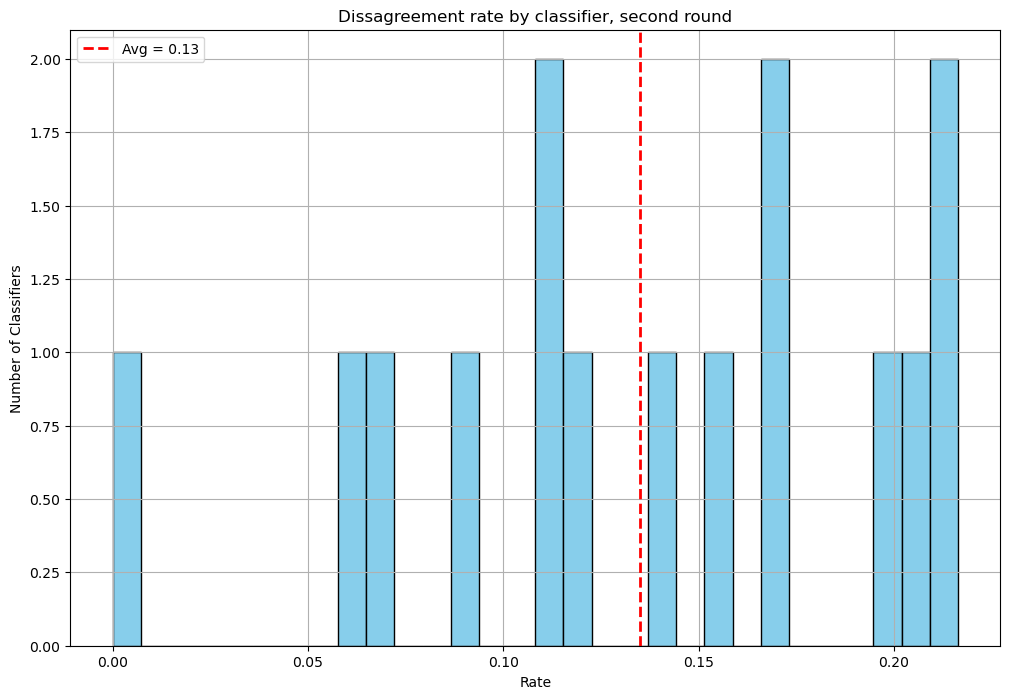

In [26]:
overall_avg = disagreement_by_classifier_second['disagreement_rate'].mean()
# Plot the histogram with average line
plt.figure(figsize=(12, 8))
plt.hist(disagreement_by_classifier_second['disagreement_rate'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(overall_avg, color='red', linestyle='dashed', linewidth=2, label=f'Avg = {overall_avg:.2f}')
#plt.axvline(0.06, color='gray', linestyle='dashed', linewidth=2, label=f'Threshold = {0.06:.2f}')
plt.title('Dissagreement rate by classifier, second round')
plt.xlabel('Rate')
plt.ylabel('Number of Classifiers')
plt.legend()
plt.grid(True)
plt.show()

All of the ads that receive at least one 'not_remote' in the second classification

In [27]:
len(classifications_m.loc[(classifications_m['classification_first'] == 'WFH') & (classifications_m['classification_second'] == 'not_remote')]['ad_id'].unique())

493

Ads with two WFH and two not_remote

In [28]:
# Define a mapping
classification_mapping = {
    'tot_remote': 'WFH',
    'temp_remote': 'WFH_partial',
    'semi_remote': 'WFH_partial',
    'semi_presence': 'WFH_partial',
    'not_clear_remote': 'WFH_partial',
    'not_remote': 'Not WFH'
}

# Apply the mapping
second_round['classification'] = second_round['classification'].replace(classification_mapping)

In [29]:
classifications_m = pd.merge(first_round, second_round, on='ad_id', how='outer', suffixes=('_first', '_second'))

In [30]:
# Group by ad_id and count occurrences for each condition
grouped = classifications_m.groupby('ad_id').agg(
    count_WFH = ('classification_first', lambda x: (x == 'WFH').sum()),
    count_not_remote = ('classification_second', lambda x: (x == 'Not WFH').sum())
)

# Filter ad_ids that have exactly 2 "WFH" and 2 "not_remote"
selected_ads = grouped[(grouped['count_WFH'] == 2) & (grouped['count_not_remote'] == 2)]

# Get the number of such ad_ids
result = len(selected_ads)
print("Number of ad_ids with two 'WFH' and two 'not_remote':", result)

Number of ad_ids with two 'WFH' and two 'not_remote': 39


In [31]:
grouped = first_round.groupby('ad_id').agg(
    count_wfh = ('classification', lambda x: (x == 'WFH').sum())
)

In [32]:
first_round[first_round['classification'] == 'WFH']

,id,classifier_id,ad_id,classification,ease,workday,timestamp
15,15,6,3826451,WFH,hard,not clear,2024-07-14 19:17:06.597599
16,16,6,5423587,WFH,easy,not clear,2024-07-14 19:18:47.900291
17,17,6,4052452,WFH,easy,full,2024-07-14 19:19:35.489201
20,20,6,5298346,WFH,easy,full,2024-07-14 19:22:49.578868
29,29,6,4078590,WFH,easy,not clear,2024-07-14 19:28:48.432925
...,...,...,...,...,...,...,...
15988,15989,52,5637026,WFH,hard,full,2024-09-01 22:48:36.864955
15990,15991,49,4272781,WFH,easy,full,2024-09-01 22:49:42.234000
15993,15994,52,4056026,WFH,easy,full,2024-09-01 22:52:47.65054
15995,15996,52,4095979,WFH,easy,full,2024-09-01 22:55:13.311093


In [33]:
classifications_m['classification_second'].value_counts()

classification_second
WFH_partial    5472
WFH            3092
Not WFH        1696
Name: count, dtype: int64

In [34]:
# Group by ad_id and count occurrences for each condition
grouped = classifications_m.groupby('ad_id').agg(
    count_WFH = ('classification_first', lambda x: (x == 'WFH').sum()),
    count_notWFH = ('classification_first', lambda x: (x == 'Not WFH').sum()),

    count_wfh1 = ('classification_second', lambda x: (x == 'WFH').sum()),
    count_hybrd = ('classification_second', lambda x: (x == 'WFH_partial').sum()),
    count_not2 = ('classification_second', lambda x: (x == 'Not WFH').sum())     
)

# Filter ad_ids that have exactly 2 "WFH" and 2 "not_remote"
selected_ads = grouped[(grouped['count_WFH'] == 2) & (grouped['count_wfh1'] == 2)]

# Get the number of such ad_ids
result = len(selected_ads)
print("Number of ad_ids with two 'WFH' and two 'not_remote':", result)

Number of ad_ids with two 'WFH' and two 'not_remote': 25


## Times and exploration

In [16]:
# 1. Preprocessing
first_round['timestamp'] = pd.to_datetime(first_round['timestamp'], errors='coerce')
first_round = first_round.sort_values(by=['classifier_id', 'timestamp'])

In [17]:
first_round['timestamp']

142     2024-07-15 13:33:25.666300
143     2024-07-15 13:35:44.933894
144     2024-07-15 13:36:45.320168
145     2024-07-15 13:41:43.197331
146     2024-07-15 13:43:16.533477
                   ...            
15472   2024-08-28 00:42:42.043298
15473   2024-08-28 00:42:55.905238
15474   2024-08-28 00:43:25.661042
15475   2024-08-28 00:43:44.323311
15476   2024-08-28 00:44:03.183795
Name: timestamp, Length: 16000, dtype: datetime64[ns]

In [18]:
# 2. Time taken per classification (per user)
first_round['time_diff'] = first_round.groupby('classifier_id')['timestamp'].diff().dt.total_seconds()
first_round['time_diff_min'] = first_round['time_diff'] / 60

In [19]:
# 3. Agreement Analysis
# Compare the two classifications for each ad_id
ad_group = first_round.groupby('ad_id').agg({
    'classification': list,
    'ease': list
}).reset_index()

def compute_agreement(row):
    if len(row['classification']) == 2:
        return row['classification'][0] == row['classification'][1]
    return None

def classify_confidence(row):
    if len(row['classification']) != 2:
        return 'unknown'
    agree = row['classification'][0] == row['classification'][1]
    ease = row['ease']
    if agree and all(e == 'easy' for e in ease):
        return 'high'
    elif agree:
        return 'medium'
    else:
        return 'low'

In [20]:
ad_group['agreement'] = ad_group.apply(compute_agreement, axis=1)
ad_group['confidence'] = ad_group.apply(classify_confidence, axis=1)

In [22]:
# 4. Per-classifier statistics
classifier_stats = first_round.groupby('classifier_id').agg(
    avg_time_per_ad=('time_diff', 'mean'),
    std_time_per_ad=('time_diff', 'std'),
    fast_classifications=('time_diff', lambda x: (x < 10).sum()),
    total_classifications=('id', 'count'),
    ease_easy=('ease', lambda x: (x == 'easy').sum()),
    ease_medium=('ease', lambda x: (x == 'medium').sum()),
    ease_hard=('ease', lambda x: (x == 'hard').sum())
).reset_index()

In [24]:
# Agreement rate per classifier
first_with_agreement = first_round.merge(ad_group[['ad_id', 'agreement', 'confidence']], on='ad_id', how='left')
agreement_per_classifier = first_with_agreement.groupby('classifier_id')['agreement'].mean().reset_index().rename(columns={'agreement': 'agreement_rate'})

In [25]:
# Combine stats
classifier_summary = pd.merge(classifier_stats, agreement_per_classifier, on='classifier_id', how='left')

In [43]:
classifier_summary.to_csv('datos/summary.csv')

## Time distributions

We want to define sessions and thresholds based on ads length

In [27]:
# 1. Preprocessing
first_round['timestamp'] = pd.to_datetime(first_round['timestamp'], errors='coerce')
first_round = first_round.sort_values(by=['classifier_id', 'timestamp'])

In [28]:
# 2. Time taken per classification (per user)
first_round['time_diff'] = first_round.groupby('classifier_id')['timestamp'].diff().dt.total_seconds()
first_round['time_diff_min'] = first_round['time_diff'] / 60

In [29]:
file_path = "_tempavisos.dta"

chunk_size = 10000
chunks = pd.read_stata(file_path, columns=['avisoid', 'avisocargo', 'avisocuerpo', 'disponibilidadnombre', 'avisorequisitos', 'avisolugartrabajo'], chunksize=chunk_size)

avisos = pd.DataFrame()

for chunk in chunks:
    avisos = pd.concat([avisos, chunk], ignore_index=True)

In [30]:
avisos = pd.merge(first_round, avisos, left_on='ad_id', right_on='avisoid', how='left')

In [31]:
avisos['aviso'] = avisos[['avisocargo', 'avisocuerpo', 'disponibilidadnombre', 'avisorequisitos', 'avisolugartrabajo']].apply(
    lambda row: ' '.join(row.dropna().astype(str)), axis=1
)

In [32]:
# Function to clean HTML tags
def remove_html_tags(text):
    if pd.isnull(text):
        return ""
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)

# Clean and count words
avisos['aviso'] = avisos['aviso'].apply(remove_html_tags)
avisos['word_count'] = avisos['aviso'].apply(lambda x: len(x.split()))

In [41]:
# Parameters in minutes
avg_lecture_word_min = 250
idle_time = 5

# Expected time based on reading speed + 3 minutes thinking time
avisos['expected_time_sec'] = (avisos['word_count'] / (avg_lecture_word_min / 60)) + (idle_time * 60)

In [42]:
# Keep time_diff only if it's within the expected range
avisos['valid_time_diff'] = avisos.apply(
    lambda row: row['time_diff'] if row['time_diff'] is not None and row['time_diff'] <= row['expected_time_sec'] else None,
    axis=1
)

### Just speed

In [43]:
# Compute average valid time per classifier
avisos['speed'] = avisos['word_count'] / avisos['time_diff']

In [44]:
avg_speed_per_classifier = avisos.groupby('classifier_id')['speed'].mean().dropna()

In [45]:
clean_speed = avg_speed_per_classifier.replace([np.inf, -np.inf], np.nan).dropna()

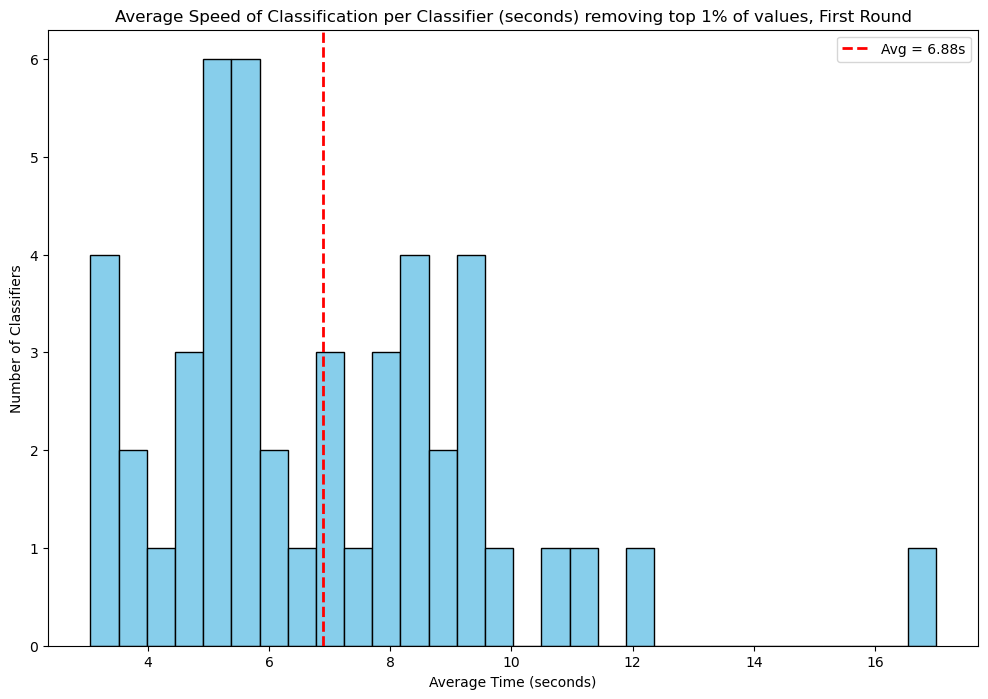

In [46]:
# Remove the top 1% of values
upper_limit = np.percentile(clean_speed, 99)
filtered_speed = clean_speed[clean_speed <= upper_limit]

plt.figure(figsize=(12, 8))
plt.hist(filtered_speed, bins=30, color='skyblue', edgecolor='black')
plt.axvline(filtered_speed.mean(), color='red', linestyle='dashed', linewidth=2,
            label=f'Avg = {filtered_speed.mean():.2f}s')
plt.title('Average Speed of Classification per Classifier (seconds) removing top 1% of values, First Round')
plt.xlabel('Average Time (seconds)')
plt.ylabel('Number of Classifiers')
plt.legend()
plt.show()


### Vaild time

In [47]:
# Convert valid_time_diff to numeric just in case
avisos['valid_time_diff'] = pd.to_numeric(avisos['valid_time_diff'], errors='coerce')

# Compute average valid time per classifier
avg_valid_time_per_classifier = avisos.groupby('classifier_id')['valid_time_diff'].mean().dropna()

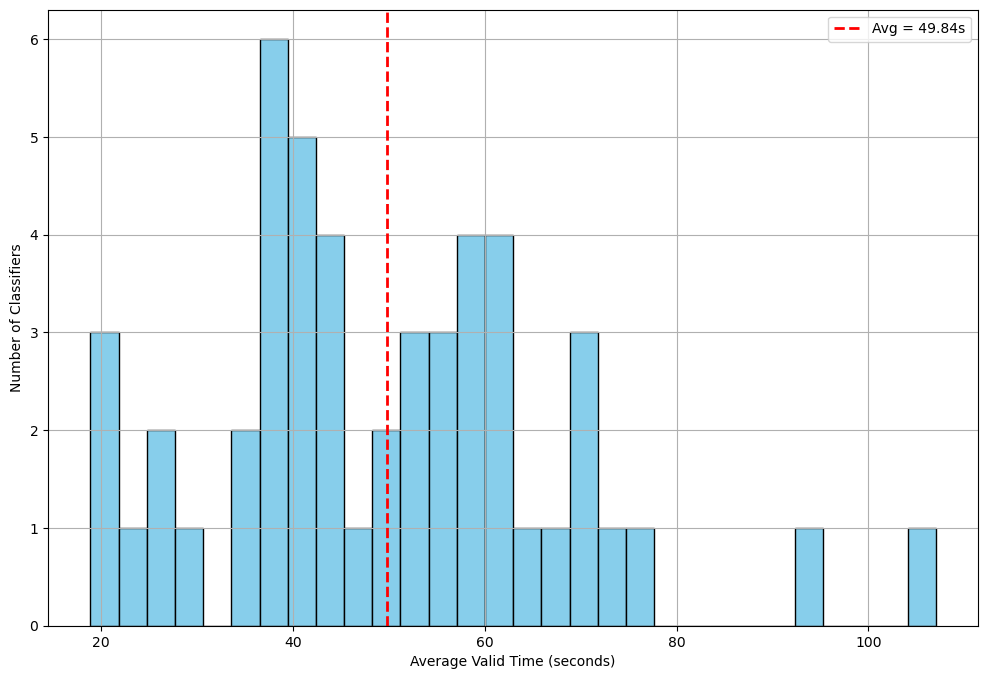

In [49]:
overall_avg = avg_valid_time_per_classifier.mean()
# Plot the histogram with average line
plt.figure(figsize=(12, 8))
plt.hist(avg_valid_time_per_classifier, bins=30, color='skyblue', edgecolor='black')
plt.axvline(overall_avg, color='red', linestyle='dashed', linewidth=2, label=f'Avg = {overall_avg:.2f}s')
#plt.title('Average Valid Time per Classification by Classifier (seconds), first round')
plt.xlabel('Average Valid Time (seconds)')
plt.ylabel('Number of Classifiers')
plt.legend()
plt.grid(True)
plt.show()

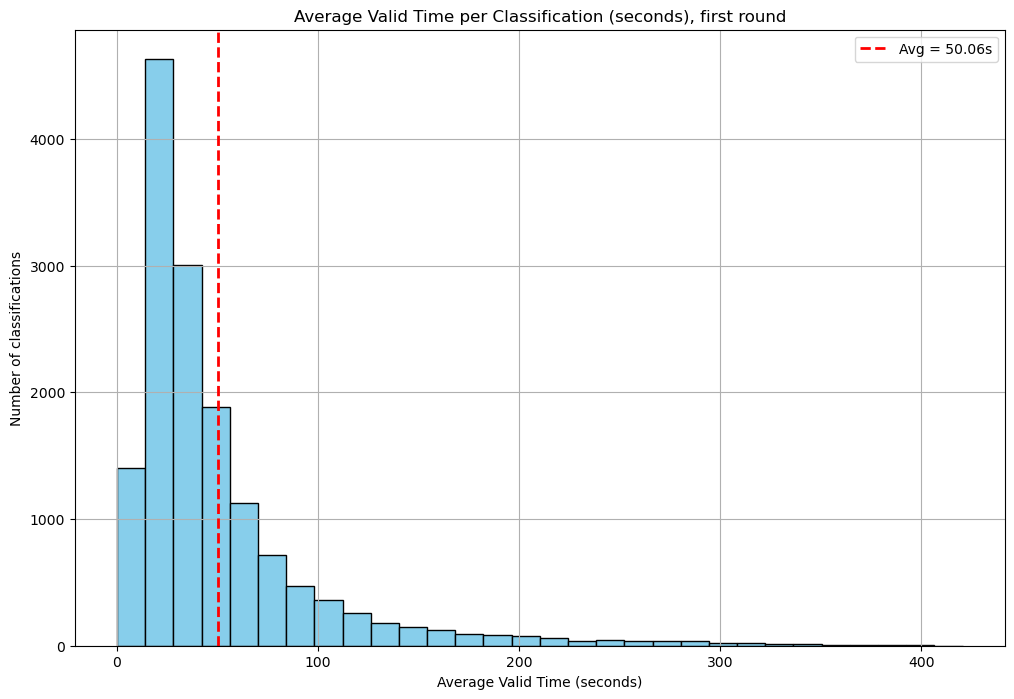

In [52]:
overall_avg = avisos['valid_time_diff'].mean()
# Plot the histogram with average line
plt.figure(figsize=(12, 8))
plt.hist(avisos['valid_time_diff'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(overall_avg, color='red', linestyle='dashed', linewidth=2, label=f'Avg = {overall_avg:.2f}s')
plt.title('Average Valid Time per Classification (seconds), first round')
plt.xlabel('Average Valid Time (seconds)')
plt.ylabel('Number of classifications')
plt.legend()
plt.grid(True)
plt.show()

### Just reading speed (number of words / time of reading) per tag

In [53]:
# Compute average valid time per classifier
avisos['speed'] = avisos['word_count'] / avisos['time_diff']
clean_speed = avisos['speed'].replace([np.inf, -np.inf], np.nan).dropna()

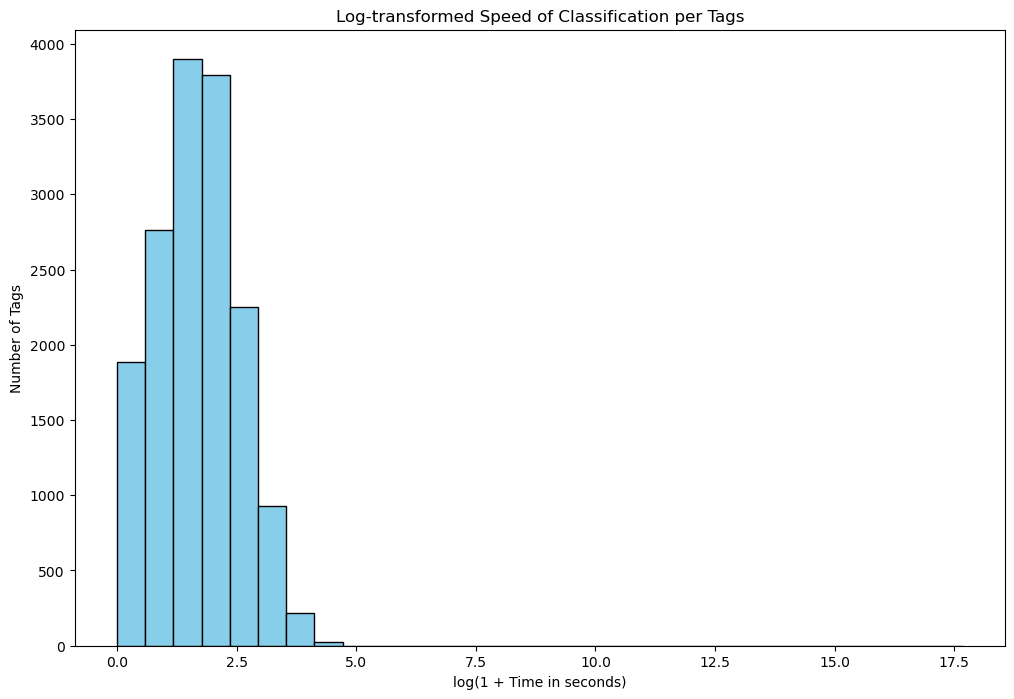

In [54]:
plt.figure(figsize=(12, 8))
plt.hist(np.log1p(clean_speed), bins=30, color='skyblue', edgecolor='black')
plt.title('Log-transformed Speed of Classification per Tags')
plt.xlabel('log(1 + Time in seconds)')
plt.ylabel('Number of Tags')
plt.show()


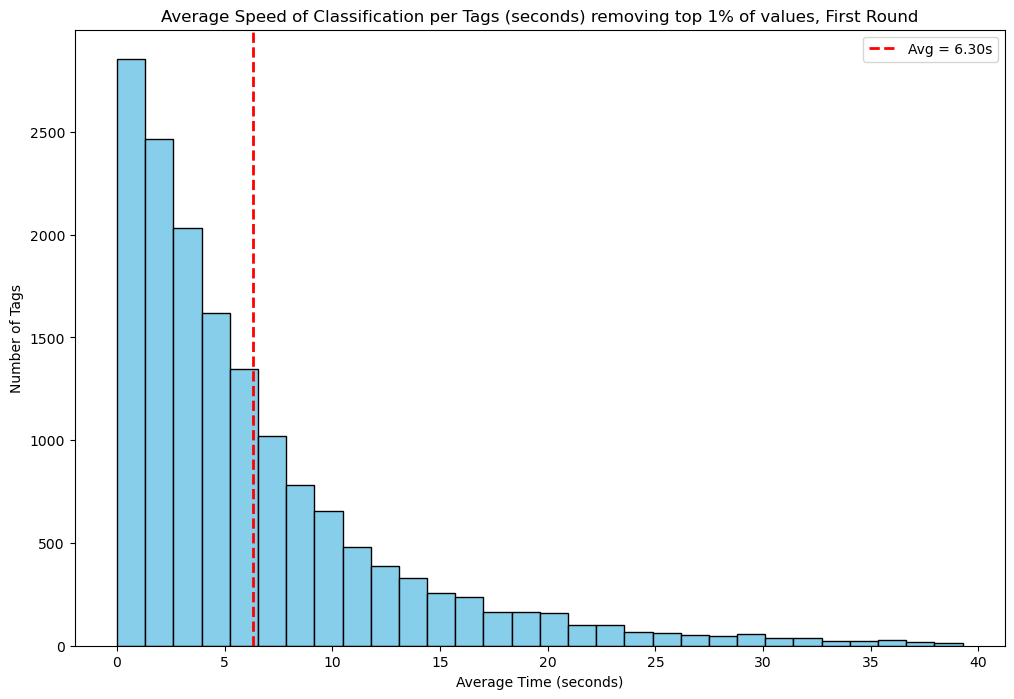

In [55]:
# Remove the top 1% of values
upper_limit = np.percentile(clean_speed, 99)
filtered_speed = clean_speed[clean_speed <= upper_limit]

plt.figure(figsize=(12, 8))
plt.hist(filtered_speed, bins=30, color='skyblue', edgecolor='black')
plt.axvline(filtered_speed.mean(), color='red', linestyle='dashed', linewidth=2,
            label=f'Avg = {filtered_speed.mean():.2f}s')
plt.title('Average Speed of Classification per Tags (seconds) removing top 1% of values, First Round')
plt.xlabel('Average Time (seconds)')
plt.ylabel('Number of Tags')
plt.legend()
plt.show()


### Saving

In [56]:
avisos.columns

Index(['id', 'classifier_id', 'ad_id', 'classification', 'ease', 'workday',
       'timestamp', 'time_diff', 'time_diff_min', 'avisoid', 'avisocargo',
       'avisocuerpo', 'disponibilidadnombre', 'avisorequisitos',
       'avisolugartrabajo', 'aviso', 'word_count', 'expected_time_sec',
       'valid_time_diff', 'speed'],
      dtype='object')

In [57]:
avisos[['id', 'classifier_id', 'ad_id', 'classification', 'ease', 'workday',
       'timestamp', 'time_diff', 'time_diff_min', 'aviso', 'word_count', 'expected_time_sec',
       'valid_time_diff']].to_csv('datos/classification first round/classification_first_round.csv', sep='\t')

### Second round

In [58]:
# 1. Preprocessing
second_round['timestamp'] = pd.to_datetime(second_round['timestamp'], errors='coerce')
second_round = second_round.sort_values(by=['classifier_id', 'timestamp'])

In [59]:
# 2. Time taken per classification (per user)
second_round['time_diff'] = second_round.groupby('classifier_id')['timestamp'].diff().dt.total_seconds()
second_round['time_diff_min'] = second_round['time_diff'] / 60

Reduce classifications to three categories

In [60]:
# Define a mapping
classification_mapping = {
    'tot_remote': 'WFH',
    'temp_remote': 'WFH_partial',
    'semi_remote': 'WFH_partial',
    'semi_presence': 'WFH_partial',
    'not_clear_remote': 'WFH_partial',
    'not_remote': 'Not WFH'
}

# Apply the mapping
second_round['classification'] = second_round['classification'].replace(classification_mapping)

In [61]:
file_path = "_tempavisos.dta"

chunk_size = 10000
chunks = pd.read_stata(file_path, columns=['avisoid', 'avisocargo', 'avisocuerpo', 'disponibilidadnombre', 'avisorequisitos', 'avisolugartrabajo'], chunksize=chunk_size)

avisos = pd.DataFrame()

for chunk in chunks:
    avisos = pd.concat([avisos, chunk], ignore_index=True)

In [62]:
avisos = pd.merge(second_round, avisos, left_on='ad_id', right_on='avisoid', how='left')

In [63]:
avisos['aviso'] = avisos[['avisocargo', 'avisocuerpo', 'disponibilidadnombre', 'avisorequisitos', 'avisolugartrabajo']].apply(
    lambda row: ' '.join(row.dropna().astype(str)), axis=1
)

In [64]:
# Function to clean HTML tags
def remove_html_tags(text):
    if pd.isnull(text):
        return ""
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)

# Clean and count words
avisos['aviso'] = avisos['aviso'].apply(remove_html_tags)
avisos['word_count'] = avisos['aviso'].apply(lambda x: len(x.split()))

In [65]:
# Parameters in minutes
avg_lecture_word_min = 250
idle_time = 5

# Expected time based on reading speed + 3 minutes thinking time
avisos['expected_time_sec'] = (avisos['word_count'] / (avg_lecture_word_min / 60)) + (idle_time * 60)

### Just speed

In [66]:
# Compute average valid time per classifier
avisos['speed'] = avisos['word_count'] / avisos['time_diff']

In [67]:
avg_speed_per_classifier = avisos.groupby('classifier_id')['speed'].mean().dropna()

In [68]:
clean_speed = avg_speed_per_classifier.replace([np.inf, -np.inf], np.nan).dropna()

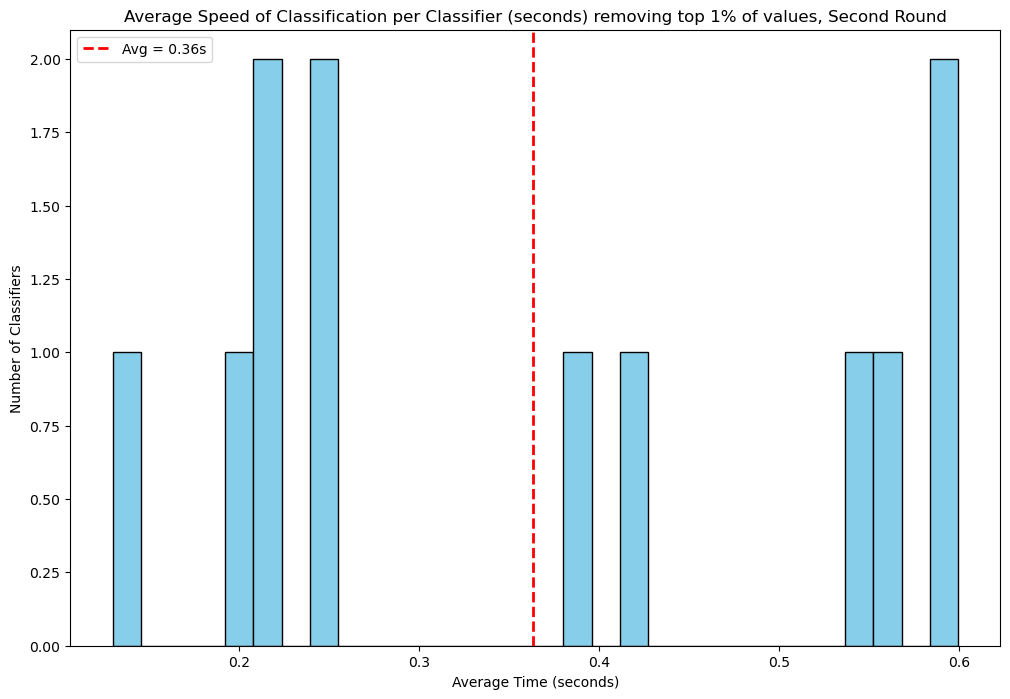

In [69]:
# Remove the top 1% of values
upper_limit = np.percentile(clean_speed, 99)
filtered_speed = clean_speed[clean_speed <= upper_limit]

plt.figure(figsize=(12, 8))
plt.hist(filtered_speed, bins=30, color='skyblue', edgecolor='black')
plt.axvline(filtered_speed.mean(), color='red', linestyle='dashed', linewidth=2,
            label=f'Avg = {filtered_speed.mean():.2f}s')
plt.title('Average Speed of Classification per Classifier (seconds) removing top 1% of values, Second Round')
plt.xlabel('Average Time (seconds)')
plt.ylabel('Number of Classifiers')
plt.legend()
plt.show()


### Valid time

In [70]:
# Keep time_diff only if it's within the expected range
avisos['valid_time_diff'] = avisos.apply(
    lambda row: row['time_diff'] if row['time_diff'] is not None and row['time_diff'] <= row['expected_time_sec'] else None,
    axis=1
)

In [71]:
# Convert valid_time_diff to numeric just in case
avisos['valid_time_diff'] = pd.to_numeric(avisos['valid_time_diff'], errors='coerce')

# Compute average valid time per classifier
avg_valid_time_per_classifier = avisos.groupby('classifier_id')['valid_time_diff'].mean().dropna()

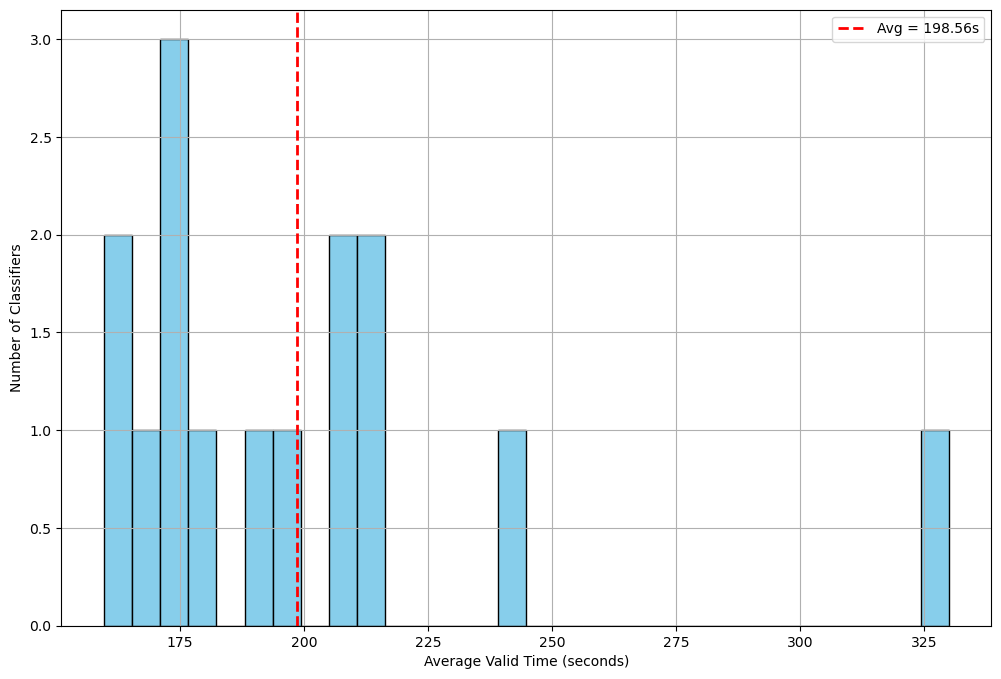

In [74]:
overall_avg = avg_valid_time_per_classifier.mean()
# Plot the histogram with average line
plt.figure(figsize=(12, 8))
plt.hist(avg_valid_time_per_classifier, bins=30, color='skyblue', edgecolor='black')
plt.axvline(overall_avg, color='red', linestyle='dashed', linewidth=2, label=f'Avg = {overall_avg:.2f}s')
#plt.title('Average Valid Time per Classification by Classifier (seconds), second round')
plt.xlabel('Average Valid Time (seconds)')
plt.ylabel('Number of Classifiers')
plt.legend()
plt.grid(True)
plt.show()

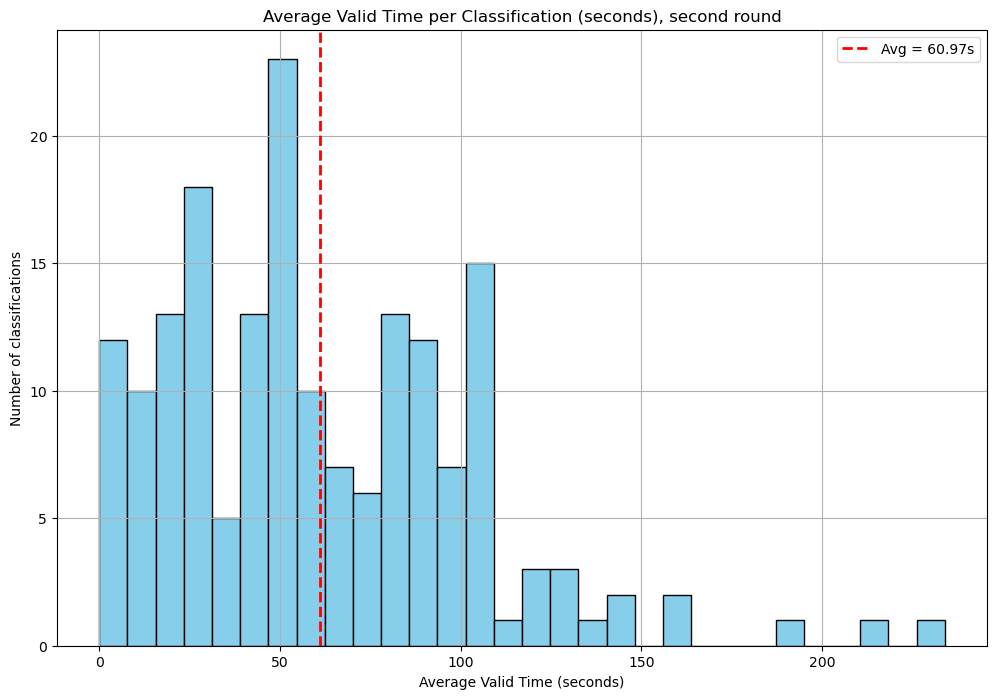

In [107]:
overall_avg = avisos['valid_time_diff'].mean()
# Plot the histogram with average line
plt.figure(figsize=(12, 8))
plt.hist(avisos['valid_time_diff'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(overall_avg, color='red', linestyle='dashed', linewidth=2, label=f'Avg = {overall_avg:.2f}s')
plt.title('Average Valid Time per Classification (seconds), second round')
plt.xlabel('Average Valid Time (seconds)')
plt.ylabel('Number of classifications')
plt.legend()
plt.grid(True)
plt.show()

### Just reading speed (number of words / time of reading) per tag

In [108]:
# Compute average valid time per classifier
avisos['speed'] = avisos['word_count'] / avisos['time_diff']
clean_speed = avisos['speed'].replace([np.inf, -np.inf], np.nan).dropna()

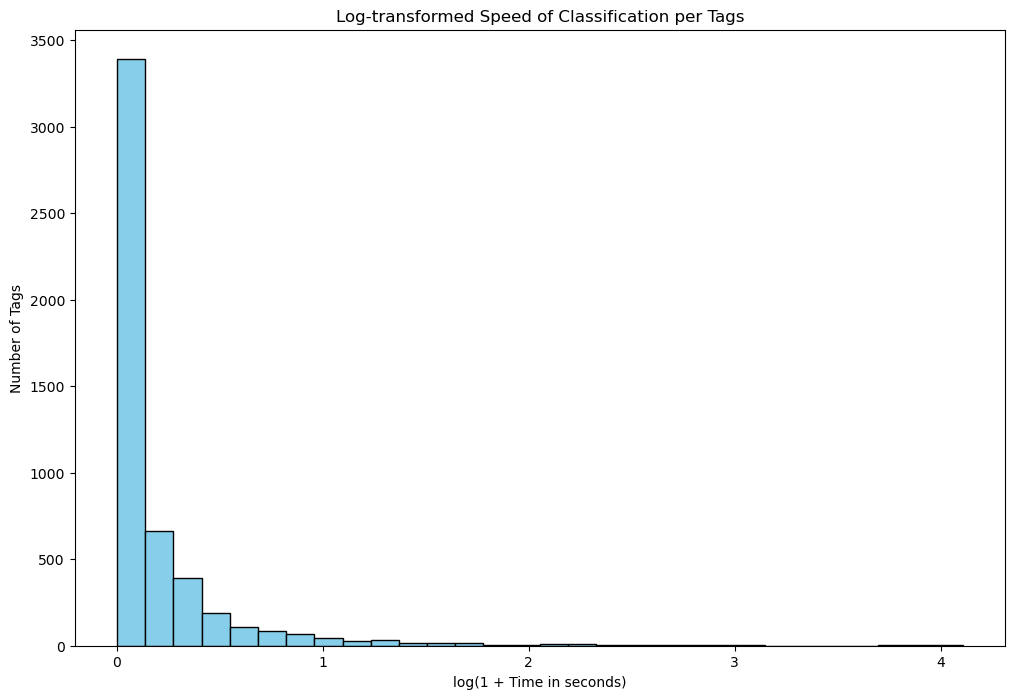

In [109]:
plt.figure(figsize=(12, 8))
plt.hist(np.log1p(clean_speed), bins=30, color='skyblue', edgecolor='black')
plt.title('Log-transformed Speed of Classification per Tags')
plt.xlabel('log(1 + Time in seconds)')
plt.ylabel('Number of Tags')
plt.show()


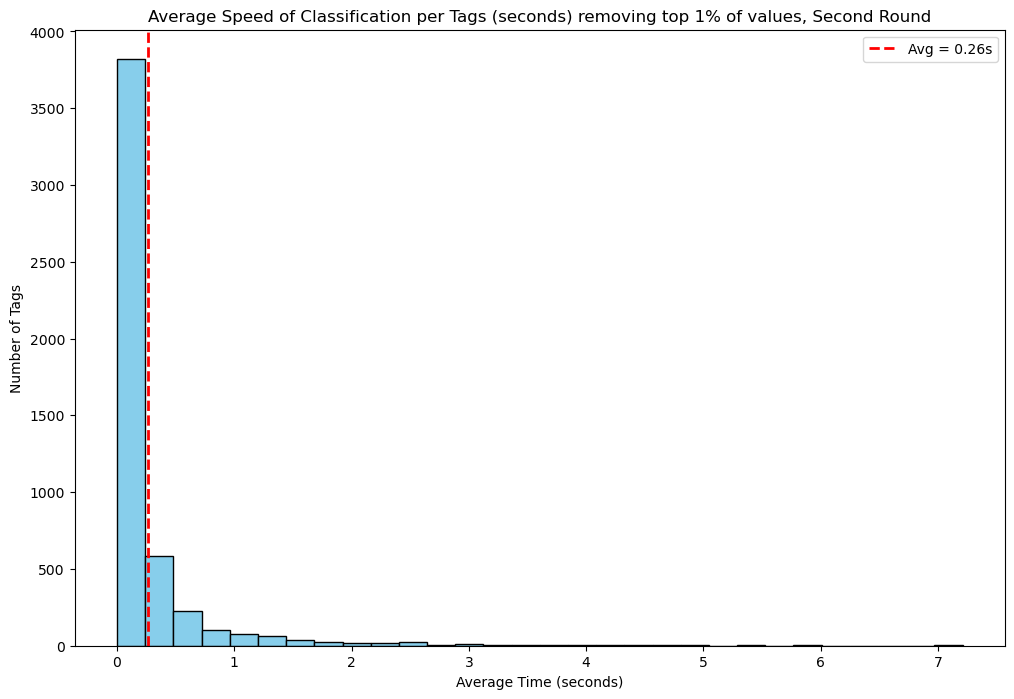

In [110]:
# Remove the top 1% of values
upper_limit = np.percentile(clean_speed, 99)
filtered_speed = clean_speed[clean_speed <= upper_limit]

plt.figure(figsize=(12, 8))
plt.hist(filtered_speed, bins=30, color='skyblue', edgecolor='black')
plt.axvline(filtered_speed.mean(), color='red', linestyle='dashed', linewidth=2,
            label=f'Avg = {filtered_speed.mean():.2f}s')
plt.title('Average Speed of Classification per Tags (seconds) removing top 1% of values, Second Round')
plt.xlabel('Average Time (seconds)')
plt.ylabel('Number of Tags')
plt.legend()
plt.show()


In [111]:
avisos.columns

Index(['id', 'classifier_id', 'ad_id', 'classification', 'ease', 'timestamp',
       'time_diff', 'time_diff_min', 'avisoid', 'avisocargo', 'avisocuerpo',
       'disponibilidadnombre', 'avisorequisitos', 'avisolugartrabajo', 'aviso',
       'word_count', 'expected_time_sec', 'speed', 'valid_time_diff'],
      dtype='object')

In [169]:
avisos[['id', 'classifier_id', 'ad_id', 'classification', 'ease', 'timestamp',
       'classification_simplified', 'time_diff', 'time_diff_min', 'aviso', 'word_count', 
       'expected_time_sec', 'valid_time_diff']].to_csv('datos/classification second_round/second_round_classifciation.csv', sep='\t')

## Correlation between time and agreement cap 10 minutes

We want to see the correlation betwee time difference and agreement

### First round

#### Speed

In [54]:
# 1. Preprocessing
first_round['timestamp'] = pd.to_datetime(first_round['timestamp'], errors='coerce')
first_round = first_round.sort_values(by=['classifier_id', 'timestamp'])

In [55]:
# 2. Time taken per classification (per user)
first_round['time_diff'] = first_round.groupby('classifier_id')['timestamp'].diff().dt.total_seconds()
first_round['time_diff_min'] = first_round['time_diff'] / 60

In [59]:
# We keep just time differences that are less than 10 minutes
first_round_10 = first_round.loc[first_round['time_diff_min'] < 10]

In [74]:
file_path = "_tempavisos.dta"

chunk_size = 10000
chunks = pd.read_stata(file_path, columns=['avisoid', 'avisocargo', 'avisocuerpo', 'disponibilidadnombre', 'avisorequisitos', 'avisolugartrabajo'], chunksize=chunk_size)

avisos = pd.DataFrame()

for chunk in chunks:
    avisos = pd.concat([avisos, chunk], ignore_index=True)

In [76]:
avisos = pd.merge(first_round_10, avisos, left_on='ad_id', right_on='avisoid', how='left')

In [77]:
avisos['aviso'] = avisos[['avisocargo', 'avisocuerpo', 'disponibilidadnombre', 'avisorequisitos', 'avisolugartrabajo']].apply(
    lambda row: ' '.join(row.dropna().astype(str)), axis=1
)

In [78]:
# Function to clean HTML tags
def remove_html_tags(text):
    if pd.isnull(text):
        return ""
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)

# Clean and count words
avisos['aviso'] = avisos['aviso'].apply(remove_html_tags)
avisos['word_count'] = avisos['aviso'].apply(lambda x: len(x.split()))

In [80]:
# Compute average time per classifier
avisos['speed'] = avisos['word_count'] / avisos['time_diff']

In [81]:
avg_speed_per_classifier = avisos.groupby('classifier_id')['speed'].mean().dropna()

In [82]:
clean_speed = avg_speed_per_classifier.replace([np.inf, -np.inf], np.nan).dropna()

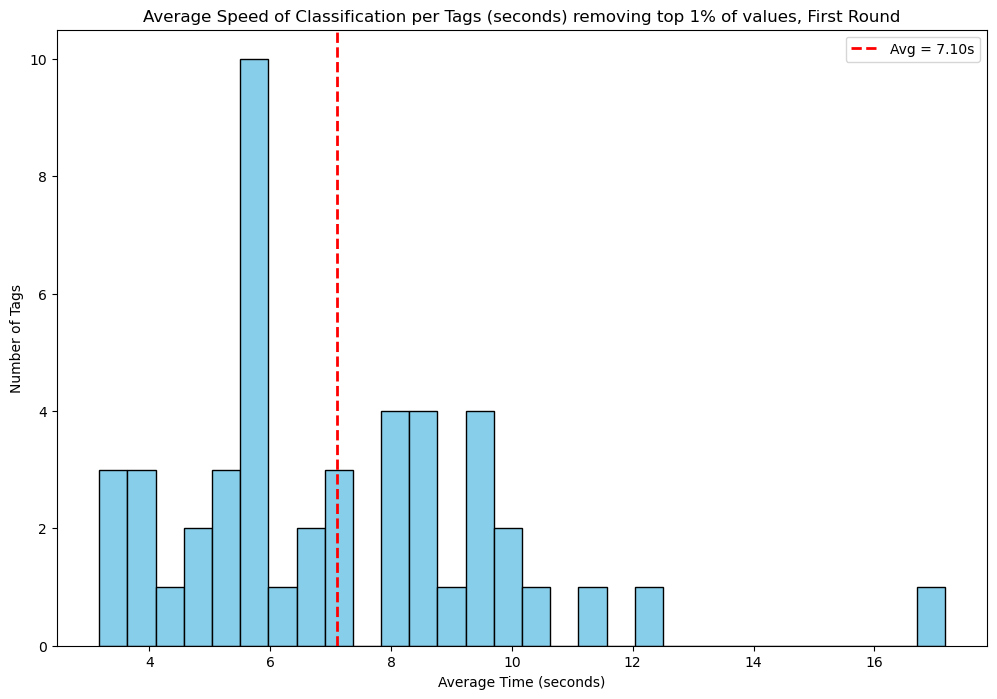

In [98]:
# Remove the top 1% of values
upper_limit = np.percentile(clean_speed, 99)
filtered_speed = clean_speed[clean_speed <= upper_limit]

plt.figure(figsize=(12, 8))
plt.hist(filtered_speed, bins=30, color='skyblue', edgecolor='black')
plt.axvline(filtered_speed.mean(), color='red', linestyle='dashed', linewidth=2,
            label=f'Avg = {filtered_speed.mean():.2f}s')
plt.title('Average Speed of Classification per Tags (seconds) removing top 1% of values, First Round')
plt.xlabel('Average Time (seconds)')
plt.ylabel('Number of Tags')
plt.legend()
plt.show()


#### Agreement

In [116]:
# Step 1: For each ad, determine if the classifications agree or disagree
# We assume each ad appears exactly twice.
ad_agreement = first_round.groupby('ad_id')['classification'].nunique().reset_index()
ad_agreement['disagreement'] = ad_agreement['classification'].apply(lambda x: 0 if x == 1 else 1)

# Step 2: Merge the disagreement indicator back to the original DataFrame
df_first = first_round.merge(ad_agreement[['ad_id', 'disagreement']], on='ad_id', how='left')

# Step 3: For each classifier, compute:
#   - The total number of ads classified
#   - The sum of disagreements (i.e. the number of ads for which their classification did not match the other classifier's)
disagreement_by_classifier = df_first.groupby('classifier_id')['disagreement'].agg(total_ads='count', total_disagreements='sum')
disagreement_by_classifier['disagreement_rate'] = disagreement_by_classifier['total_disagreements'] / disagreement_by_classifier['total_ads']

scatter plot

In [124]:
disagreement_by_classifier['speed'] = clean_speed

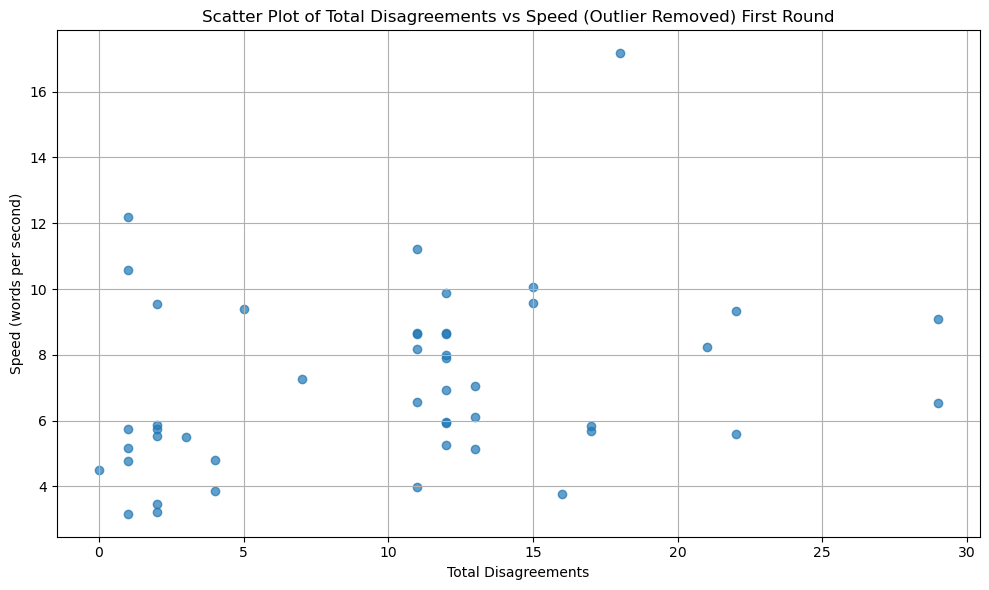

In [132]:
# Drop rows with missing speed
disagreement_speed = disagreement_by_classifier.dropna(subset=['speed'])

# Remove extreme outlier
# Remove points above 99th percentile
q99 = disagreement_speed['speed'].quantile(0.99)
disagreement_speed = disagreement_speed[disagreement_speed['speed'] < q99]


# Plot
plt.figure(figsize=(10, 6))
plt.scatter(disagreement_speed['total_disagreements'], disagreement_speed['speed'], alpha=0.7)

# Labels and title
plt.xlabel('Total Disagreements')
plt.ylabel('Speed (words per second)')
plt.title('Scatter Plot of Total Disagreements vs Speed (Outlier Removed) First Round')
plt.grid(True)


plt.tight_layout()
plt.show()


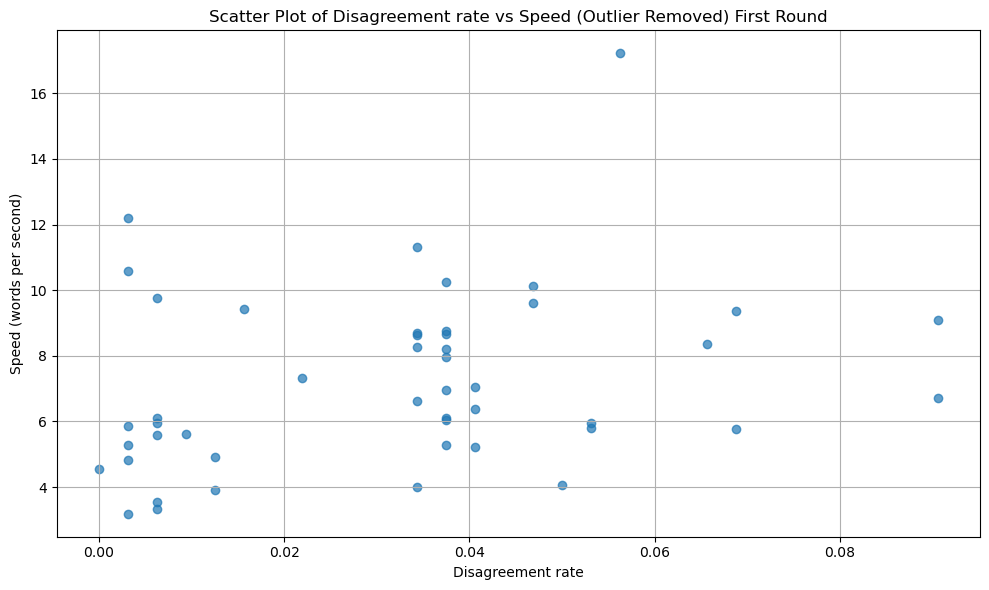

In [181]:
# Drop rows with missing speed
disagreement_speed = disagreement_by_classifier.dropna(subset=['speed'])

# Remove extreme outlier
# Remove points above 99th percentile
q99 = disagreement_speed['speed'].quantile(0.99)
disagreement_speed = disagreement_speed[disagreement_speed['speed'] < q99]


# Plot
plt.figure(figsize=(10, 6))
plt.scatter(disagreement_speed['disagreement_rate'], disagreement_speed['speed'], alpha=0.7)

# Labels and title
plt.xlabel('Disagreement rate')
plt.ylabel('Speed (words per second)')
plt.title('Scatter Plot of Disagreement rate vs Speed (Outlier Removed) First Round')
plt.grid(True)

plt.tight_layout()
plt.show()


### Second round

#### Speed

In [99]:
# 1. Preprocessing
second_round['timestamp'] = pd.to_datetime(second_round['timestamp'], errors='coerce')
second_round = second_round.sort_values(by=['classifier_id', 'timestamp'])

In [100]:
# 2. Time taken per classification (per user)
second_round['time_diff'] = second_round.groupby('classifier_id')['timestamp'].diff().dt.total_seconds()
second_round['time_diff_min'] = second_round['time_diff'] / 60

In [101]:
# We keep just time differences that are less than 10 minutes
second_round_10 = second_round.loc[second_round['time_diff_min'] < 10]

In [102]:
file_path = "_tempavisos.dta"

chunk_size = 10000
chunks = pd.read_stata(file_path, columns=['avisoid', 'avisocargo', 'avisocuerpo', 'disponibilidadnombre', 'avisorequisitos', 'avisolugartrabajo'], chunksize=chunk_size)

avisos = pd.DataFrame()

for chunk in chunks:
    avisos = pd.concat([avisos, chunk], ignore_index=True)

In [103]:
avisos = pd.merge(second_round_10, avisos, left_on='ad_id', right_on='avisoid', how='left')

In [104]:
avisos['aviso'] = avisos[['avisocargo', 'avisocuerpo', 'disponibilidadnombre', 'avisorequisitos', 'avisolugartrabajo']].apply(
    lambda row: ' '.join(row.dropna().astype(str)), axis=1
)

In [105]:
# Function to clean HTML tags
def remove_html_tags(text):
    if pd.isnull(text):
        return ""
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)

# Clean and count words
avisos['aviso'] = avisos['aviso'].apply(remove_html_tags)
avisos['word_count'] = avisos['aviso'].apply(lambda x: len(x.split()))

In [106]:
# Compute average time per classifier
avisos['speed'] = avisos['word_count'] / avisos['time_diff']

In [107]:
avg_speed_per_classifier = avisos.groupby('classifier_id')['speed'].mean().dropna()

In [108]:
clean_speed_sr = avg_speed_per_classifier.replace([np.inf, -np.inf], np.nan).dropna()

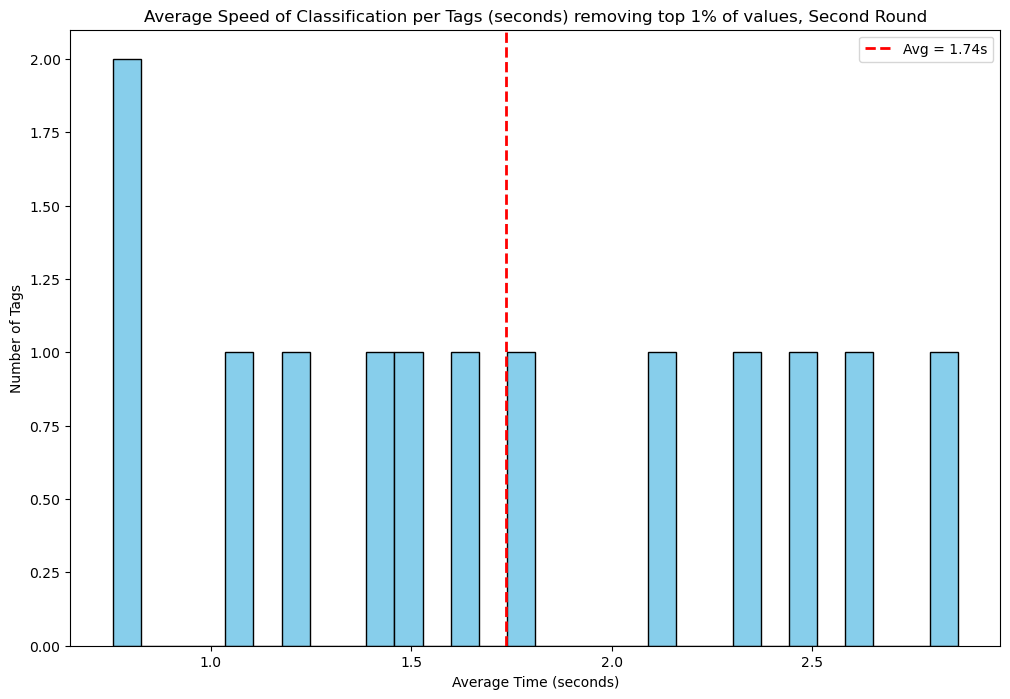

In [111]:
# Remove the top 1% of values
filtered_speed = clean_speed_sr

plt.figure(figsize=(12, 8))
plt.hist(filtered_speed, bins=30, color='skyblue', edgecolor='black')
plt.axvline(filtered_speed.mean(), color='red', linestyle='dashed', linewidth=2,
            label=f'Avg = {filtered_speed.mean():.2f}s')
plt.title('Average Speed of Classification per Tags (seconds) removing top 1% of values, Second Round')
plt.xlabel('Average Time (seconds)')
plt.ylabel('Number of Tags')
plt.legend()
plt.show()


#### Agreement

In [135]:
# Define a mapping
classification_mapping = {
    'tot_remote': 'WFH',
    'temp_remote': 'WFH_partial',
    'semi_remote': 'WFH_partial',
    'semi_presence': 'WFH_partial',
    'not_clear_remote': 'WFH_partial',
    'not_remote': 'Not WFH'
}

# Apply the mapping
second_round['classification'] = second_round['classification'].replace(classification_mapping)

In [137]:
# Step 1: For each ad, determine if the classifications agree or disagree
# We assume each ad appears exactly twice.
ad_agreement = second_round.groupby('ad_id')['classification'].nunique().reset_index()
ad_agreement['disagreement'] = ad_agreement['classification'].apply(lambda x: 0 if x == 1 else 1)

# Step 2: Merge the disagreement indicator back to the original DataFrame
df_second = second_round.merge(ad_agreement[['ad_id', 'disagreement']], on='ad_id', how='left')

# Step 3: For each classifier, compute:
#   - The total number of ads classified
#   - The sum of disagreements (i.e. the number of ads for which their classification did not match the other classifier's)
disagreement_by_classifier_sr = df_second.groupby('classifier_id')['disagreement'].agg(total_ads='count', total_disagreements='sum')
disagreement_by_classifier_sr['disagreement_rate'] = disagreement_by_classifier_sr['total_disagreements'] / disagreement_by_classifier_sr['total_ads']

scatter plot

In [150]:
disagreement_by_classifier_sr = disagreement_by_classifier_sr.loc[disagreement_by_classifier_sr['disagreement_rate'] != 0]

In [151]:
disagreement_by_classifier_sr['speed'] = clean_speed_sr

/tmp/ipykernel_25198/3821158278.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  disagreement_by_classifier_sr['speed'] = clean_speed_sr


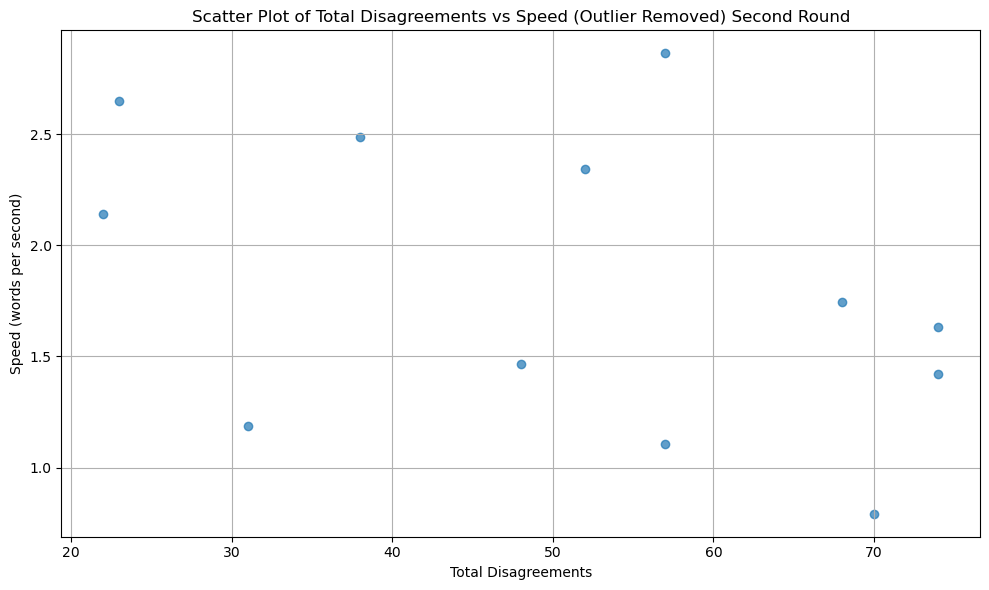

In [153]:
# Drop rows with missing speed
disagreement_speed = disagreement_by_classifier_sr.dropna(subset=['speed'])

# Remove extreme outlier
# Remove points above 99th percentile
#q99 = disagreement_speed['speed'].quantile(0.99)
#disagreement_speed = disagreement_speed[disagreement_speed['speed'] < q99]


# Plot
plt.figure(figsize=(10, 6))
plt.scatter(disagreement_speed['total_disagreements'], disagreement_speed['speed'], alpha=0.7)

# Labels and title
plt.xlabel('Total Disagreements')
plt.ylabel('Speed (words per second)')
plt.title('Scatter Plot of Total Disagreements vs Speed (Outlier Removed) Second Round')
plt.grid(True)


plt.tight_layout()
plt.show()


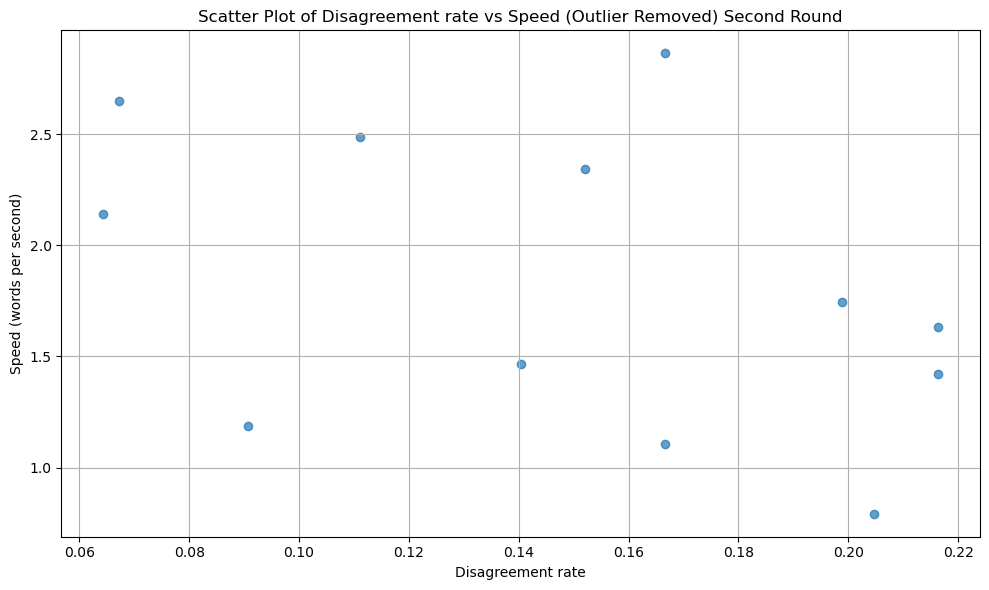

In [154]:
# Drop rows with missing speed
disagreement_speed = disagreement_by_classifier_sr.dropna(subset=['speed'])

# Remove extreme outlier
# Remove points above 99th percentile
#q99 = disagreement_speed['speed'].quantile(0.99)
#disagreement_speed = disagreement_speed[disagreement_speed['speed'] < q99]


# Plot
plt.figure(figsize=(10, 6))
plt.scatter(disagreement_speed['disagreement_rate'], disagreement_speed['speed'], alpha=0.7)

# Labels and title
plt.xlabel('Disagreement rate')
plt.ylabel('Speed (words per second)')
plt.title('Scatter Plot of Disagreement rate vs Speed (Outlier Removed) Second Round')
plt.grid(True)

plt.tight_layout()
plt.show()
